In [6]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

sys.path.insert(0, str(Path.cwd()))

from scipy.spatial import ConvexHull
from algorithm.vertexModelBubbles import blend_projected_points, project_points_to_ellipsoid
from algorithm.vertexModel import add_faces_and_vertices_to_x, create_tetrahedra


In [2]:
def generate_ellipsoid(axes, centre=np.array([0.0, 0.0, 0.0]), n_u=50, n_v=25):
    """
    Generate x, y, z surface coordinates for plotting an ellipsoid.
    """

    u = np.linspace(0, 2 * np.pi, n_u)
    v = np.linspace(0, np.pi, n_v)

    x = axes[0] * np.outer(np.cos(u), np.sin(v)) + centre[0]
    y = axes[1] * np.outer(np.sin(u), np.sin(v)) + centre[1]
    z = axes[2] * np.outer(np.ones_like(u), np.cos(v)) + centre[2]

    return x, y, z


def generate_surface_directions(n_points=16):
    """
    Generate approximately even radial directions on a unit sphere using equal-area
    latitude rings.
    """

    directions = []
    total_area = 4 * np.pi
    area_per_point = total_area / n_points
    distance = np.sqrt(area_per_point)
    M_theta = max(1, int(round(np.pi / distance)))
    d_theta = np.pi / M_theta
    d_phi = area_per_point / d_theta

    for m in range(M_theta):
        theta = np.pi * (m + 0.5) / M_theta
        M_phi = max(1, int(round(2 * np.pi * np.sin(theta) / d_phi)))

        for n in range(M_phi):
            phi = 2 * np.pi * n / M_phi
            x = np.sin(theta) * np.cos(phi)
            y = np.sin(theta) * np.sin(phi)
            z = np.cos(theta)
            directions.append([x, y, z])

    directions = np.array(directions)
    return directions[:n_points]


def place_cyst_seeds(
    n_points=16,
    center=np.array([0.0, 0.0, 0.0]),
    inner_axes=np.array([4.0, 3.0, 2.5]),
    outer_axes=np.array([6.0, 4.5, 3.5]),
    alpha=0.5,
    max_step=None,
):
    centre = np.asarray(center, dtype=float)
    directions = generate_surface_directions(n_points)

    inner_points = project_points_to_ellipsoid(
        directions,
        inner_axes,
        centre
    )

    outer_points = project_points_to_ellipsoid(
        directions,
        outer_axes,
        centre
    )

    epithelial_points = blend_projected_points(
        inner_points,
        outer_points,
        alpha,
        max_step=max_step,
    )

    return {
        "directions": directions,
        "inner_points": inner_points,
        "outer_points": outer_points,
        "epithelial_points": epithelial_points,
    }


def plot_cyst_seed_layout(result, center=np.array([0.0, 0.0, 0.0]), inner_axes=np.array([4.0, 3.0, 2.5]), outer_axes=np.array([8.0, 4.0, 3])):
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')

    inner_x, inner_y, inner_z = generate_ellipsoid(inner_axes, centre=center)
    outer_x, outer_y, outer_z = generate_ellipsoid(outer_axes, centre=center)

    ax.plot_surface(inner_x, inner_y, inner_z, color='none', edgecolor='tab:blue', linewidth=0.1, alpha=0.05)
    ax.plot_surface(outer_x, outer_y, outer_z, color='none', edgecolor='tab:orange', linewidth=0.1, alpha=0.05)

    ax.scatter(*center, color='black', s=80, label='lumen centre')
    ax.scatter(*result['inner_points'].T, color='tab:blue', s=40, label='inner/lumen points')
    ax.scatter(*result['outer_points'].T, color='tab:orange', s=40, label='outer points')
    ax.scatter(*result['epithelial_points'].T, color='tab:green', s=70, label='epithelial cell centres')

    for i in range(len(result['inner_points'])):
        ax.plot(
            [result['inner_points'][i, 0], result['outer_points'][i, 0]],
            [result['inner_points'][i, 1], result['outer_points'][i, 1]],
            [result['inner_points'][i, 2], result['outer_points'][i, 2]],
            color='gray',
            alpha=0.8,
            linewidth=0.9,
        )

    ax.set_title('Ellipsoid-based cyst ')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    
    ax.legend(loc='upper right', fontsize=8)
    plt.tight_layout()
    plt.show()


def _set_axes_equal_3d(ax):
    """Set equal aspect ratio on a 3D matplotlib axis."""
    limits = np.array([ax.get_xlim3d(), ax.get_ylim3d(), ax.get_zlim3d()])
    center = limits.mean(axis=1)
    radius = 0.5 * np.max(limits[:, 1] - limits[:, 0])
    ax.set_xlim3d([center[0] - radius, center[0] + radius])
    ax.set_ylim3d([center[1] - radius, center[1] + radius])
    ax.set_zlim3d([center[2] - radius, center[2] + radius])


def plot_surface_topology(topology, points, ax=None, color='gray', alpha=0.6, linewidth=0.7):
    """
    Plot the convex-hull triangulation of per-cell surface points.

    `points` must be ordered by cell ID: row i corresponds to cell i + 1.
    """
    if ax is None:
        fig = plt.figure(figsize=(8, 8))
        ax = fig.add_subplot(111, projection='3d')

    for tri in topology['triangles_connectivity']:
        tri_pts = points[tri - 1]
        tri_loop = np.vstack((tri_pts, tri_pts[0]))
        ax.plot(tri_loop[:, 0], tri_loop[:, 1], tri_loop[:, 2], color=color, alpha=alpha, linewidth=linewidth)

    return ax


def plot_cyst_mesh(
    mesh,
    ax=None,
    show_apical=True,
    show_basal=True,
    show_lateral=True,
    show_cell_centers=False,
    apical_color='tab:blue',
    basal_color='tab:orange',
    lateral_color='gray',
    alpha=0.8,
    linewidth=0.6,
):
    """
    Plot the apical/basal surface wireframe and lateral edges of a cyst mesh.
    """
    if ax is None:
        fig = plt.figure(figsize=(10, 10))
        ax = fig.add_subplot(111, projection='3d')
        standalone = True
    else:
        standalone = False

    topology = mesh['topology']
    apical_vertices = mesh['apical_vertices']
    basal_vertices = mesh['basal_vertices']

    for cell_edges in topology['cell_edges']:
        for v1, v2 in cell_edges:
            if show_apical:
                ax.plot(
                    [apical_vertices[v1, 0], apical_vertices[v2, 0]],
                    [apical_vertices[v1, 1], apical_vertices[v2, 1]],
                    [apical_vertices[v1, 2], apical_vertices[v2, 2]],
                    color=apical_color,
                    alpha=alpha,
                    linewidth=linewidth,
                )
            if show_basal:
                ax.plot(
                    [basal_vertices[v1, 0], basal_vertices[v2, 0]],
                    [basal_vertices[v1, 1], basal_vertices[v2, 1]],
                    [basal_vertices[v1, 2], basal_vertices[v2, 2]],
                    color=basal_color,
                    alpha=alpha,
                    linewidth=linewidth,
                )

    if show_lateral:
        for v_idx in range(len(apical_vertices)):
            ax.plot(
                [apical_vertices[v_idx, 0], basal_vertices[v_idx, 0]],
                [apical_vertices[v_idx, 1], basal_vertices[v_idx, 1]],
                [apical_vertices[v_idx, 2], basal_vertices[v_idx, 2]],
                color=lateral_color,
                alpha=0.35,
                linewidth=0.4,
            )

    if show_cell_centers:
        n_cells = len(topology['main_cells'])
        centers = mesh['X'][1:n_cells + 1]
        ax.scatter(
            centers[:, 0],
            centers[:, 1],
            centers[:, 2],
            color='tab:green',
            s=12,
            alpha=0.7,
            label='cell centres',
        )

    ax.set_title('Cyst epithelial mesh')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    _set_axes_equal_3d(ax)

    if standalone:
        plt.tight_layout()
        plt.show()

    return ax

In [3]:

def create_2d_surface_topology(points, center=np.array([0.0, 0.0, 0.0])):
    """
    Create surface topology from a point cloud that shares one radial layout.

    Typically `points` are unit directions from the origin; the same topology
    is then reused for inner, outer, and epithelial layers obtained by radial
    projection onto different ellipsoids.

    Cell IDs are 1..N.
    Each row in triangles_connectivity is a topological vertex:
    [cell_a, cell_b, cell_c].
    """
    points = np.asarray(points, dtype=float)
    center = np.asarray(center, dtype=float)
    n_cells = points.shape[0]
    main_cells = np.arange(1, n_cells + 1)

    hull = ConvexHull(points)

    # Convert ConvexHull's 0-based point indices to cell IDs 1..N.
    triangles_connectivity = hull.simplices.astype(int) + 1

    neighbour_edges = []
    for tri in triangles_connectivity:
        neighbour_edges.extend([
            sorted([tri[0], tri[1]]),
            sorted([tri[1], tri[2]]),
            sorted([tri[2], tri[0]]),
        ])
    neighbours_network = np.unique(np.asarray(neighbour_edges, dtype=int), axis=0)

    # Radial directions from the center to each seed point.
    cell_dirs = points - center
    cell_dirs /= np.linalg.norm(cell_dirs, axis=1, keepdims=True)

    vertex_seed_dirs = points[triangles_connectivity - 1].mean(axis=1) - center
    vertex_seed_dirs /= np.linalg.norm(vertex_seed_dirs, axis=1, keepdims=True)

    cell_edges = []
    for cell_id in main_cells:
        vertex_ids = np.where(np.any(triangles_connectivity == cell_id, axis=1))[0]

        radial = cell_dirs[cell_id - 1]
        local_dirs = vertex_seed_dirs[vertex_ids]

        tangent_a = np.cross(radial, np.array([0.0, 0.0, 1.0]))
        if np.linalg.norm(tangent_a) < 1e-8:
            tangent_a = np.cross(radial, np.array([0.0, 1.0, 0.0]))
        tangent_a /= np.linalg.norm(tangent_a)
        tangent_b = np.cross(radial, tangent_a)

        rel = local_dirs - radial
        angles = np.arctan2(rel @ tangent_b, rel @ tangent_a)
        ordered_vertex_ids = vertex_ids[np.argsort(angles)]

        cell_edges.append(
            np.column_stack([
                ordered_vertex_ids,
                np.roll(ordered_vertex_ids, -1),
            ])
        )

    return {
        "main_cells": main_cells,
        "triangles_connectivity": triangles_connectivity,
        "neighbours_network": neighbours_network,
        "cell_edges": cell_edges,
        "vertex_seed_dirs": vertex_seed_dirs,
    }


def build_cyst_mesh(result, center, inner_axes, outer_axes):
    """
    Build a cyst mesh using one shared topology derived from radial directions.

    Inner, outer, and epithelial layers all use the same connectivity; only the
    radial projection differs between apical and basal surfaces.
    """
    center = np.asarray(center, dtype=float)
    inner_axes = np.asarray(inner_axes, dtype=float)
    outer_axes = np.asarray(outer_axes, dtype=float)

    # Directions are defined from the origin; topology is angular, not ellipsoid-specific.
    topology = create_2d_surface_topology(result["directions"], center=np.zeros(3))

    n_cells = len(topology["main_cells"])

    # X index 0 is unused because cell IDs start at 1.
    X = np.zeros((n_cells + 1, 3))
    X[1:] = result["epithelial_points"]

    apical_vertices = project_points_to_ellipsoid(
        topology["vertex_seed_dirs"],
        inner_axes,
        center,
    )

    basal_vertices = project_points_to_ellipsoid(
        topology["vertex_seed_dirs"],
        outer_axes,
        center,
    )

    X, apical_face_ids, Xg_apical, apical_vertex_ids = add_faces_and_vertices_to_x(
        X,
        result["inner_points"],
        apical_vertices,
    )

    Twg_apical = create_tetrahedra(
        topology["triangles_connectivity"],
        topology["neighbours_network"],
        topology["cell_edges"],
        topology["main_cells"],
        apical_face_ids,
        apical_vertex_ids,
    )

    X, basal_face_ids, Xg_basal, basal_vertex_ids = add_faces_and_vertices_to_x(
        X,
        result["outer_points"],
        basal_vertices,
    )

    Twg_basal = create_tetrahedra(
        topology["triangles_connectivity"],
        topology["neighbours_network"],
        topology["cell_edges"],
        topology["main_cells"],
        basal_face_ids,
        basal_vertex_ids,
    )

    Twg = np.vstack([Twg_apical, Twg_basal])

    return {
        "X": X,
        "Twg": Twg,
        "topology": topology,
        "Xg_apical": Xg_apical,
        "Xg_basal": Xg_basal,
        "apical_vertices": apical_vertices,
        "basal_vertices": basal_vertices,
    }

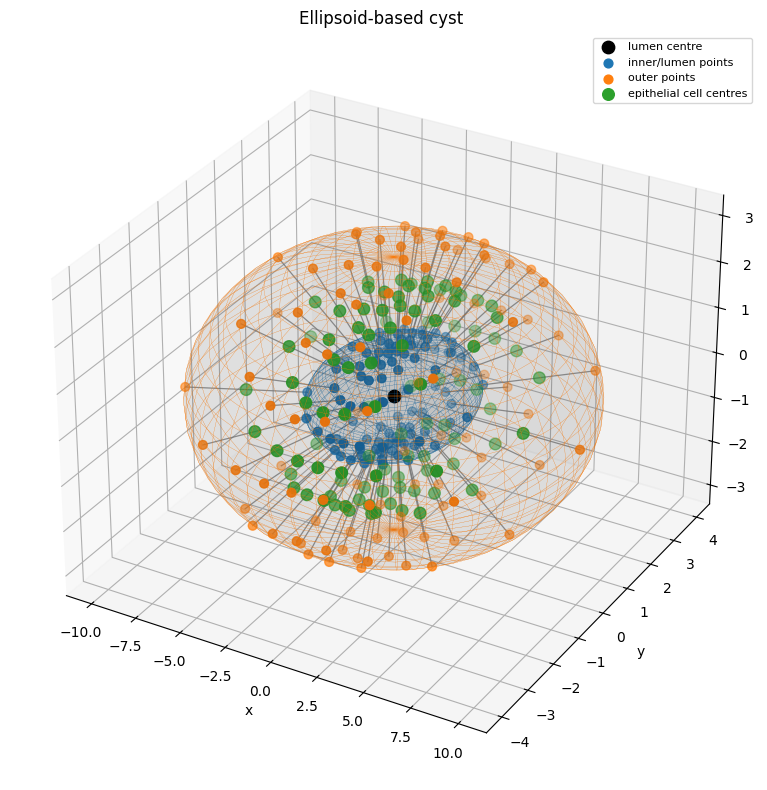

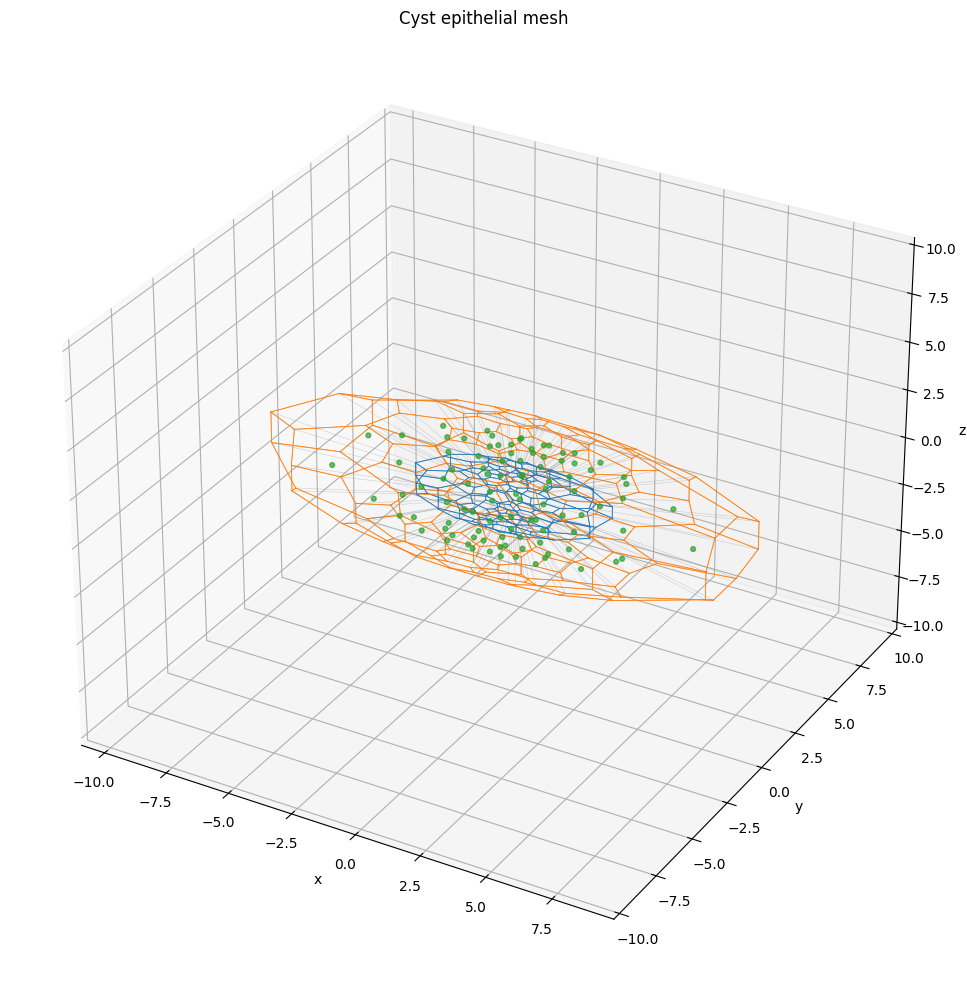

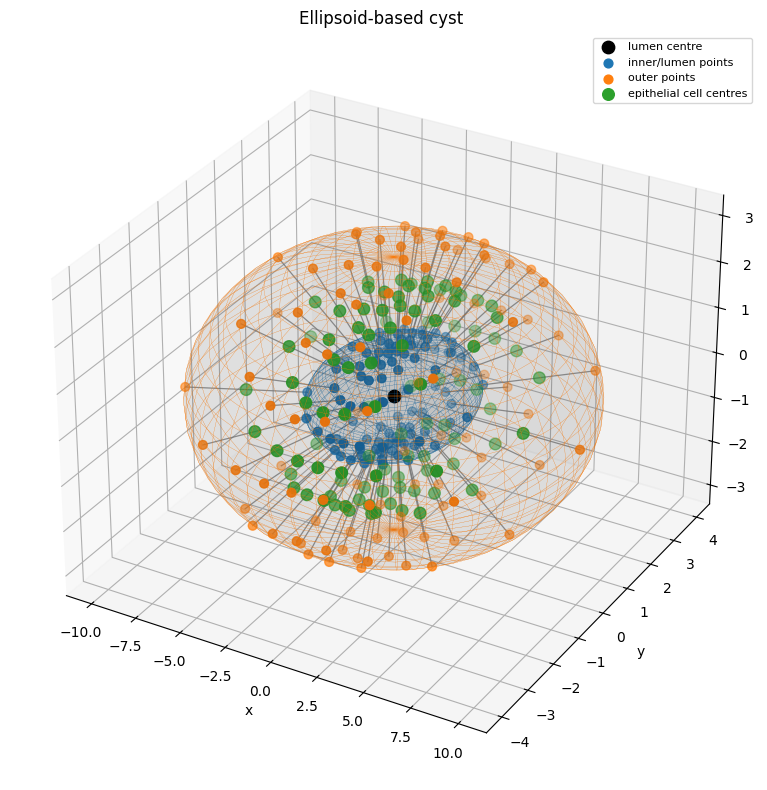

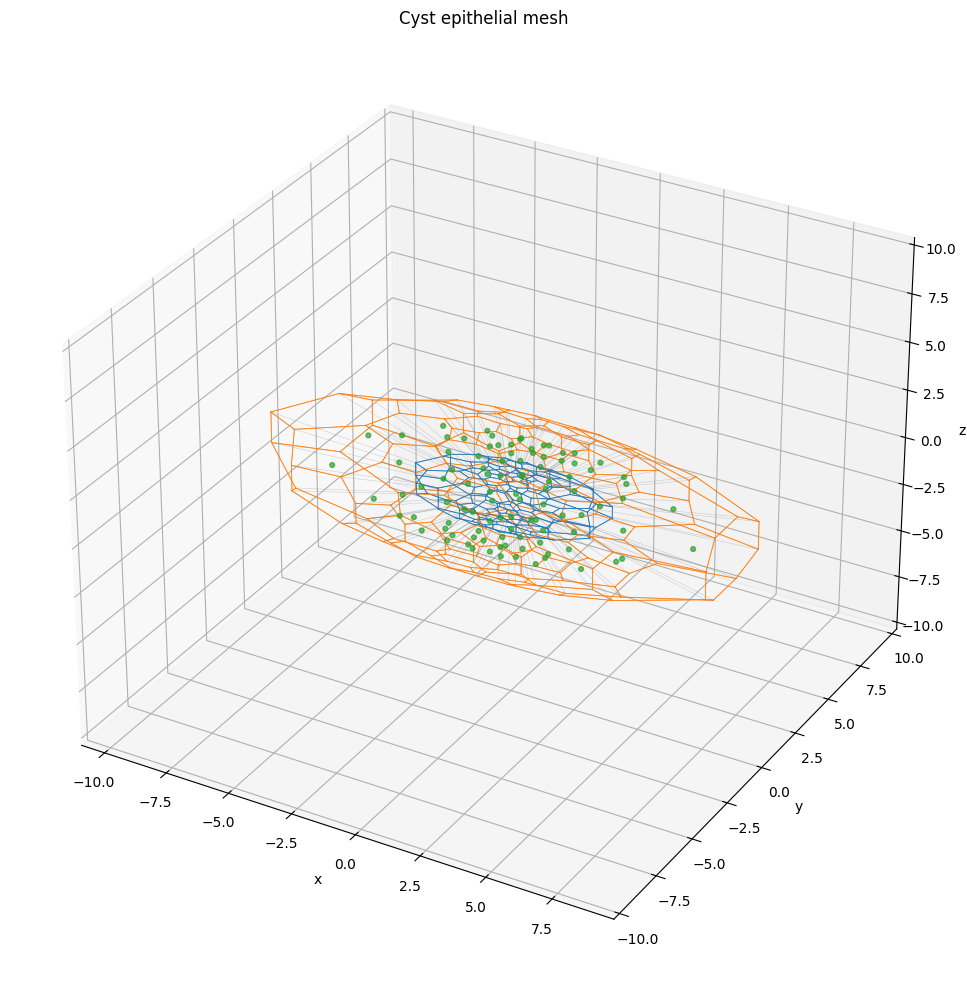

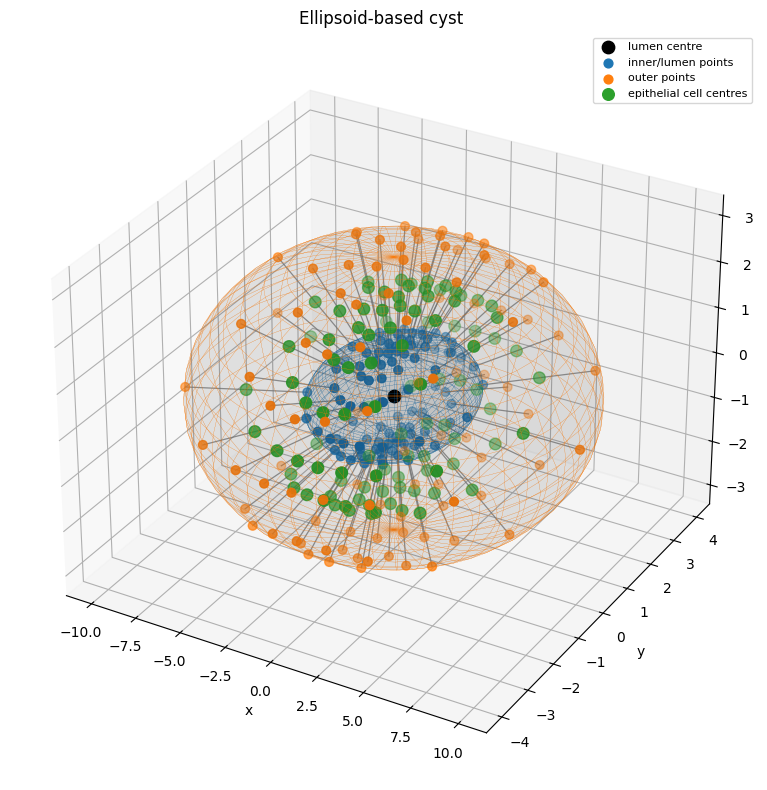

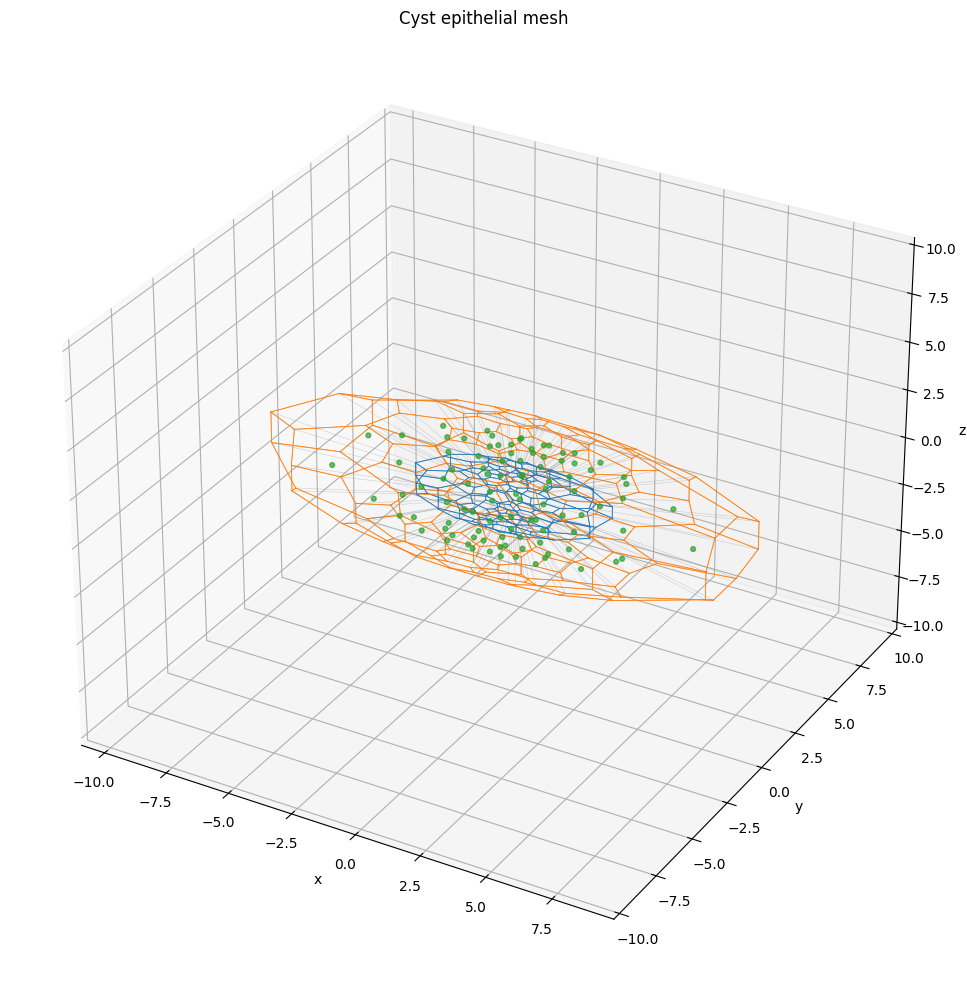

Inner points shape: (99, 3)
Outer points shape: (99, 3)
Epithelial points shape: (99, 3)
cell IDs: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96
 97 98 99]
X shape: (686, 3)
Twg shape: (2134, 4)
topological vertices: (194, 3)


In [7]:
center = np.array([0.0, 0.0, 0.0])
inner_axes = np.array([4.0, 2.0, 1])
outer_axes = np.array([10.0, 4.0, 3])

result = place_cyst_seeds(n_points=100, center=center, inner_axes=inner_axes, outer_axes=outer_axes, alpha=0.5)
mesh = build_cyst_mesh(result, center, inner_axes, outer_axes)
plot_cyst_seed_layout(result, center=center, inner_axes=inner_axes, outer_axes=outer_axes)
plot_cyst_mesh(mesh, show_cell_centers=True)

print('Inner points shape:', result['inner_points'].shape)
print('Outer points shape:', result['outer_points'].shape)
print('Epithelial points shape:', result['epithelial_points'].shape)
print("cell IDs:", mesh["topology"]["main_cells"])
print("X shape:", mesh["X"].shape)
print("Twg shape:", mesh["Twg"].shape)
print("topological vertices:", mesh["topology"]["triangles_connectivity"].shape)
